### **py3SEB for UAV Imagery**

This notebook is built to run the python-based, Three-Source Energy Balance Model (py3SEB) to quantify radiative and turbulent land surface fluxes in heterogeneous agricultural systems using high-resolution UAV imagery. Example imagery from a UAV flight over a vineyard in 2019 as well as eddy covariance data is included in the 'input_data' for running the model within the notebook. Spatial ***LE, H, Rn, and G*** maps (as well as the fractional cover and radiometric temperature maps) are included in the 'output_data' folder. <u>***This version was tested and implemented with Python 3.14.7***</u>.


For technical assistance or troubleshooting, please either email ajgal@ucdavis.edu or open an issue on the GitHub page.

Those implementing this code must cite the following sources:
   
    Burchard-Levine V, Nieto H, Riaño D, Kustas WP, Migliavacca M, El-Madany TS, Nelson JA, Andreu A, Carrara A, Beringer J, Baldocchi D, Martín MP. A remote sensing-based three-source energy balance model to improve global estimations of evapotranspiration in semi-arid tree-grass ecosystems. Glob Chang Biol. 2022 Feb;28(4):1493-1515. doi: 10.1111/gcb.16002. Epub 2021 Dec 2. PMID: 34799950.

    Burchard-Levine V, Nieto H, Kustas WP, Gao F, Alfieri JG, Prueger JH, Hipps LE, Bambach-Ortiz N, McElrone AJ, Castro SJ, Alsina MM, McKee LG, Zahn E, Bou-Zeid E, Dokoozlian N. Application of a remote-sensing three-source energy balance model to improve evapotranspiration partitioning in vineyards. Irrig Sci. 2022;40(4-5):593-608. doi: 10.1007/s00271-022-00787-x. Epub 2022 Apr 5. PMID: 36172254; PMCID: PMC9509310.

    Gal A, Burchard-Levine B, Bambach-Ortiz N, Nieto H, McElrone AJ, Knipper K, Roby M, Kustas WP, Anderson M, Torres-Rua A, Meza Capcha K, Levinson M, Tolentino P, Castro SJ, McKee L, Wright IR, Nocco MA. A three-source approach for estimating surface energy fluxes in intercropped agricultural systems using remotely sensed imagery. In prep.


### *Import Libaries and Packages*

In [47]:
import os
import numpy as np
from osgeo import gdal
from pathlib import Path
import pandas as pd
import geopandas as gpd
from pyTSEB import TSEB
from pyTSEB import meteo_utils as met
from pyTSEB import net_radiation as rad
from pyTSEB import resistances as res
from pyTSEB import energy_combination_ET as EC
from py3seb import py3seb 
import matplotlib.pyplot as plt
from osgeo import gdal
import pyDMS.pyDMSUtils as gu
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import rasterio

### *Initialize the working directories and specify input files*

In [48]:
# 1. Setup working directory & paths
user = 'ajgal' #change this to your username
os.chdir(f'/Users/{user}/Documents/GitHub/py3SEB-UAV/') # change the directory
datadir = Path('./input_data/') 
out_dir = Path('./output_data/')
uav_dir = datadir

ndvi_file = uav_dir / 'RIP_720_20190504_1025_NDVI_resampled_cc.tif'
ch_file = uav_dir / 'RIP_720_20190504_1025_CHM_resampled_cc.tif'
lst_file = uav_dir / 'RIP_720_20190504_1025_LST_resampled_cc2.tif'

meteo_file = datadir / 'RIP_723_05042019.csv'
meteo_ds = pd.read_csv(meteo_file)
meteo_ds['TIMESTAMP'] = pd.to_datetime(meteo_ds['TIMESTAMP'], format='%m/%d/%y %H:%M', errors='coerce')

In [49]:
# Open LST as the template for spatial info
lst_fid = gdal.Open(str(lst_file))
if lst_fid is None:
    raise RuntimeError(f"Cannot open LST file: {lst_file}")

# Open NDVI and CHM rasters
ndvi_ds = gdal.Open(str(ndvi_file))
if ndvi_ds is None:
    raise RuntimeError(f"Cannot open NDVI file: {ndvi_file}")

ch_ds = gdal.Open(str(ch_file))
if ch_ds is None:
    raise RuntimeError(f"Cannot open CHM file: {ch_file}")

# Get geo info from LST
gt = lst_fid.GetGeoTransform()
proj = lst_fid.GetProjection()
cols = lst_fid.RasterXSize
rows = lst_fid.RasterYSize
minx, maxy = gt[0], gt[3]
maxx = minx + gt[1] * cols
miny = maxy + gt[5] * rows
te = [minx, maxx, miny, maxy]

# Read arrays
ndvi_ar = ndvi_ds.GetRasterBand(1).ReadAsArray()
ch_ar   = ch_ds.GetRasterBand(1).ReadAsArray()
lst_ar  = lst_fid.GetRasterBand(1).ReadAsArray()

# Convert LST to Kelvin if needed (if input was in °C)
lst_ar = lst_ar + 273.15

In [50]:
# RGB file 
rgb_file = uav_dir / f'RIP_720_20190504_1025_RGBNIR_resampled_cc.tif'
rgb_fid = gdal.Open(str(rgb_file))
blue_ar = rgb_fid.GetRasterBand(3).ReadAsArray()
green_ar = rgb_fid.GetRasterBand(2).ReadAsArray()
red_ar = rgb_fid.GetRasterBand(1).ReadAsArray()

def stretch_image(image, p_min=2, p_max=98):
    stretched = np.zeros_like(image, dtype=np.float32)
    for i in range(3):  # R, G, B
        band = image[:, :, i]
        min_val = np.percentile(band, p_min)
        max_val = np.percentile(band, p_max)
        stretched[:, :, i] = np.clip((band - min_val) / (max_val - min_val), 0, 1)
    return stretched

# Stack bands and stretch
rgb_image = np.dstack((red_ar, green_ar, blue_ar))
rgb_image = stretch_image(rgb_image)

# #==============================================================================
# # contextual image classification approach to separate overstory, understory and soil
# #==============================================================================

# set up masks to isolate different layers
# overstory mask 
mask_ov = np.logical_and(ndvi_ar > 0.45, ch_ar > 1)

# understory mask 
mask_un = np.logical_and(ndvi_ar > 0.45, ch_ar < 0.4)

# soil mask 
mask_soil = np.logical_and(ndvi_ar < 0.45, ch_ar < 0.4)

# substrate mask 
mask_sub = np.logical_or(mask_un, mask_soil)

# overstory canopy temperature
Tc_ar = lst_ar.copy()
## all non-tree pixels as nan
Tc_ar[~mask_ov] = np.nan

# understory canopy temperature
Tc_sub_ar = lst_ar.copy()
## all non-grass pixels as nan
Tc_sub_ar[~mask_un] = np.nan

# soil temperature
Ts_ar = lst_ar.copy()
## all non-soil pixels as nan
Ts_ar[~mask_soil] = np.nan

# substrate temperature
Tsub_ar = lst_ar.copy()
## all non-substrate pixels as nan
Tsub_ar[~mask_un] = np.nan

## create classification array
class_ar = lst_ar.copy()
class_ar[:] = np.nan
class_ar[mask_ov] = 1
class_ar[mask_un] = 2
class_ar[mask_soil] = 3

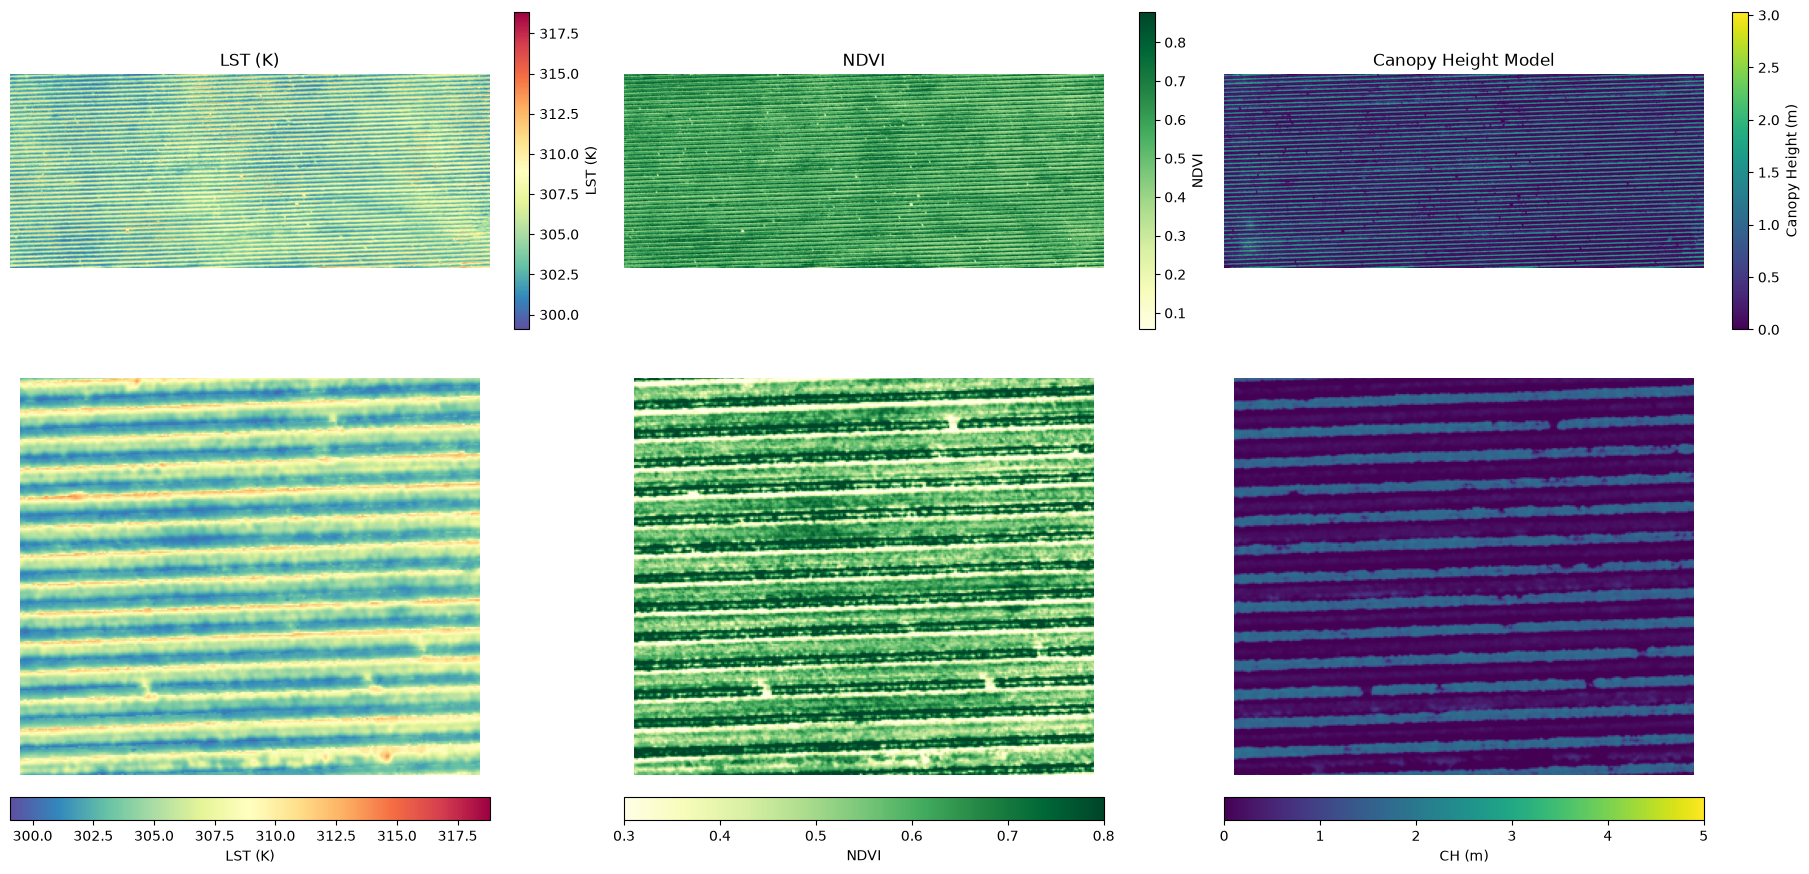

In [51]:
# Plotting
fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)

# Full LST
ax1 = axes[0, 0]
im1 = ax1.imshow(lst_ar, cmap='Spectral_r', vmin=np.nanmin(lst_ar), vmax=np.nanmax(lst_ar), extent=te)
ax1.set_title('LST (K)')
ax1.set_axis_off()
cb1 = plt.colorbar(im1, ax=ax1, shrink=0.8)
cb1.set_label('LST (K)')

# Full NDVI
ax2 = axes[0, 1]
im2 = ax2.imshow(ndvi_ar, cmap='YlGn', vmin=np.nanmin(ndvi_ar), vmax=np.nanmax(ndvi_ar), extent=te)
ax2.set_title('NDVI')
ax2.set_axis_off()
cb2 = plt.colorbar(im2, ax=ax2, shrink=0.8)
cb2.set_label('NDVI')

# Full CHM
ax3 = axes[0, 2]
im3 = ax3.imshow(ch_ar, cmap='viridis',
                 vmin=0, vmax=np.nanmax(ch_ar),
                 extent=te)
ax3.set_title('Canopy Height Model')
ax3.set_axis_off()
cb3 = plt.colorbar(im3, ax=ax3, shrink=0.8)
cb3.set_label('Canopy Height (m)')

# coordinates for zoomed in area
xmin, xmax = 751683.8, 751737.2
ymin, ymax = 4081778, 4081824

# Zoomed-in LST
ax4 = axes[1, 0]
im4 = ax4.imshow(lst_ar, cmap='Spectral_r', vmin=np.nanmin(lst_ar), vmax=np.nanmax(lst_ar), extent=te)
ax4.set_xlim(xmin, xmax)
ax4.set_ylim(ymin, ymax)
cb4 = plt.colorbar(im4, ax=ax4, orientation='horizontal')
cb4.set_label('LST (K)')
ax4.set_axis_off()

# Zoomed-in NDVI
ax5 = axes[1, 1]
im5 = ax5.imshow(ndvi_ar, cmap='YlGn', vmin=0.3, vmax=0.8, extent=te)
ax5.set_xlim(xmin, xmax)
ax5.set_ylim(ymin, ymax)
cb5 = plt.colorbar(im5, ax=ax5, orientation='horizontal')
cb5.set_label('NDVI')
ax5.set_axis_off()

# Zoomed-in CHM
ax6 = axes[1, 2]
im6 = ax6.imshow(ch_ar, cmap='viridis', vmin=0, vmax=5, extent=te)
ax6.set_xlim(xmin, xmax)
ax6.set_ylim(ymin, ymax)
cb6 = plt.colorbar(im6, ax=ax6, orientation='horizontal')
cb6.set_label('CH (m)')
ax6.set_axis_off()

plt.show()

In [52]:
# fc (tree canopy fraction)
fc_ar = lst_ar.copy()
fc_ar[mask_ov] = 1
fc_ar[~mask_ov] = 0

# fs (soil fraction)
fs_ar = lst_ar.copy()
fs_ar[mask_soil] = 1
fs_ar[~mask_soil] = 0

# fc_sub (cover crop fraction)
fc_sub_ar = lst_ar.copy()
fc_sub_ar[mask_un] = 1
fc_sub_ar[~mask_un] = 0

# set up filename for outputs (fractional covers)
## tree crop fraction
outfile_fc_mask = out_dir / f'Fc_surface_CC_10cm.tif'
## cover crop fraction
outfile_fc_sub_mask = out_dir / f'Fc_sub_surface_CC_10cm.tif'
## soil fraction
outfile_fs_mask = out_dir / f'Fs_sub_surface_CC_10cm.tif'

# set up filename for outputs (component temperatures)
outfile_Tc = out_dir / f'Tc_surface_CC_10cm.tif'
outfile_Tc_sub = out_dir / f'Tc_sub_surface_CC_10cm.tif'
outfile_Ts = out_dir / f'Ts_surface_CC_10cm.tif'
outfile_Tsub= out_dir / f'Tsub_surface_CC_10cm.tif'

rows, cols = np.shape(lst_ar)

print('Saving inputs at 10cm...')
# Save output
input_nodata = np.nan
driver = gdal.GetDriverByName('GTiff')
# Tc
ds = driver.Create(str(outfile_Tc), cols, rows, 1, gdal.GDT_Float32)
ds.SetGeoTransform(gt)
ds.SetProjection(proj)
band = ds.GetRasterBand(1)
band.SetNoDataValue(input_nodata)
band.WriteArray(Tc_ar)
band.FlushCache()
ds.FlushCache()
del ds

#Tc_sub
ds = driver.Create(str(outfile_Tc_sub), cols, rows, 1, gdal.GDT_Float32)
ds.SetGeoTransform(gt)
ds.SetProjection(proj)
band = ds.GetRasterBand(1)
band.SetNoDataValue(input_nodata)
band.WriteArray(Tc_sub_ar)
band.FlushCache()
ds.FlushCache()
del ds 

#Ts
ds = driver.Create(str(outfile_Ts), cols, rows, 1, gdal.GDT_Float32)
ds.SetGeoTransform(gt)
ds.SetProjection(proj)
band = ds.GetRasterBand(1)
band.SetNoDataValue(input_nodata)
band.WriteArray(Ts_ar)
band.FlushCache()
ds.FlushCache()
del ds

#Tsub
ds = driver.Create(str(outfile_Tsub), cols, rows, 1, gdal.GDT_Float32)
ds.SetGeoTransform(gt)
ds.SetProjection(proj)
band = ds.GetRasterBand(1)
band.SetNoDataValue(input_nodata)
band.WriteArray(Tsub_ar)
band.FlushCache()
ds.FlushCache()
del ds

#Fc
ds = driver.Create(str(outfile_fc_mask), cols, rows, 1, gdal.GDT_Float32)
ds.SetGeoTransform(gt)
ds.SetProjection(proj)

band = ds.GetRasterBand(1)
band.SetNoDataValue(input_nodata)
band.WriteArray(fc_ar)
band.FlushCache()
ds.FlushCache()
del ds 

#Fs
ds = driver.Create(str(outfile_fs_mask), cols, rows, 1, gdal.GDT_Float32)
ds.SetGeoTransform(gt)
ds.SetProjection(proj)

band = ds.GetRasterBand(1)
band.SetNoDataValue(input_nodata)
band.WriteArray(fs_ar)
band.FlushCache()
ds.FlushCache()
del ds 

#Fc_sub
ds = driver.Create(str(outfile_fc_sub_mask), cols, rows, 1, gdal.GDT_Float32)
ds.SetGeoTransform(gt)
ds.SetProjection(proj)
band = ds.GetRasterBand(1)
band.SetNoDataValue(input_nodata)
band.WriteArray(fc_sub_ar)
band.FlushCache()
ds.FlushCache()
del ds

print('Done!')

Saving inputs at 10cm...
Done!


In [53]:
# resample to 4m 
target_res = 4 # m

# set up outputfile name
outfile_fc_4m = out_dir / f'Fc_surface_CC_{target_res}m.tif'
outfile_fc_sub_4m = out_dir / f'Fc_sub_surface_CC_{target_res}m.tif'
outfile_fs_4m = out_dir / f'Fs_surface_CC_{target_res}m.tif'

outfile_Tc_4m = out_dir / f'Tc_surface_CC_{target_res}m.tif'
outfile_Tc_sub_4m = out_dir / f'Tc_sub_surface_CC_{target_res}m.tif'
outfile_Ts_4m = out_dir / f'Ts_surface_CC_{target_res}m.tif'
outfile_Tsub_4m = out_dir / f'Tsub_surface_CC_{target_res}m.tif'

outfile_lst_4m = out_dir / f'lst_surface_CC_{target_res}m.tif'

# also canopy height model 
outfile_chm_4m = out_dir / f'Hc_surface_CC_{target_res}m.tif'

print(f'Resampling inputs to {target_res}m...')

# fractional covers
gdal.Warp(str(outfile_fc_4m), str(outfile_fc_mask), format='Gtiff', xRes=target_res, yRes=target_res, resampleAlg= 'average')
gdal.Warp(str(outfile_fc_sub_4m), str(outfile_fc_sub_mask), format='Gtiff', xRes=target_res, yRes=target_res, resampleAlg= 'average')
gdal.Warp(str(outfile_fs_4m), str(outfile_fs_mask), format='Gtiff', xRes=target_res, yRes=target_res, resampleAlg= 'average')

# component temperatures
gdal.Warp(str(outfile_Tc_4m), str(outfile_Tc), format='Gtiff', xRes=target_res, yRes=target_res, resampleAlg= 'min')
gdal.Warp(str(outfile_Tc_sub_4m), str(outfile_Tc_sub), format='Gtiff', xRes=target_res, yRes=target_res, resampleAlg= 'min')
gdal.Warp(str(outfile_Ts_4m), str(outfile_Ts), format='Gtiff', xRes=target_res, yRes=target_res, resampleAlg= 'average')
gdal.Warp(str(outfile_Tsub_4m), str(outfile_Tsub), format='Gtiff', xRes=target_res, yRes=target_res, resampleAlg= 'average')

gdal.Warp(str(outfile_lst_4m), str(lst_file), format='Gtiff', xRes=target_res, yRes=target_res, resampleAlg= 'average')

# Also canopy height (get maximum in this case as this best describes surface roughness)
gdal.Warp(str(outfile_chm_4m), str(ch_file), format='Gtiff', xRes=target_res, yRes=target_res, resampleAlg= 'max')

ndvi_vine = np.where(mask_ov == 1, ndvi_ar, np.nan)
ndvi_cover = np.where(mask_un == 1, ndvi_ar, np.nan)


with rasterio.open(ndvi_file) as src:  # your original NDVI file
    profile = src.profile
    transform = src.transform

# Create a temporary GeoTIFF from your masked array
temp_ndvi_vine_file = out_dir / 'temp_ndvi_vine_masked.tif'
temp_ndvi_cover_file = out_dir / 'temp_ndvi_cover_masked.tif'

# Update profile for your masked array (single band, float32)
profile.update(dtype=rasterio.float32, count=1)

# Write the masked NDVI array to file
with rasterio.open(temp_ndvi_vine_file, 'w', **profile) as dst:
    dst.write(ndvi_vine.astype(rasterio.float32), 1)
with rasterio.open(temp_ndvi_cover_file, 'w', **profile) as dst:
    dst.write(ndvi_cover.astype(rasterio.float32), 1)

# Optional: clean up the temporary file
temp_ndvi_vine_file.unlink()
temp_ndvi_cover_file.unlink()

print(f'Done!')

Resampling inputs to 4m...
Done!


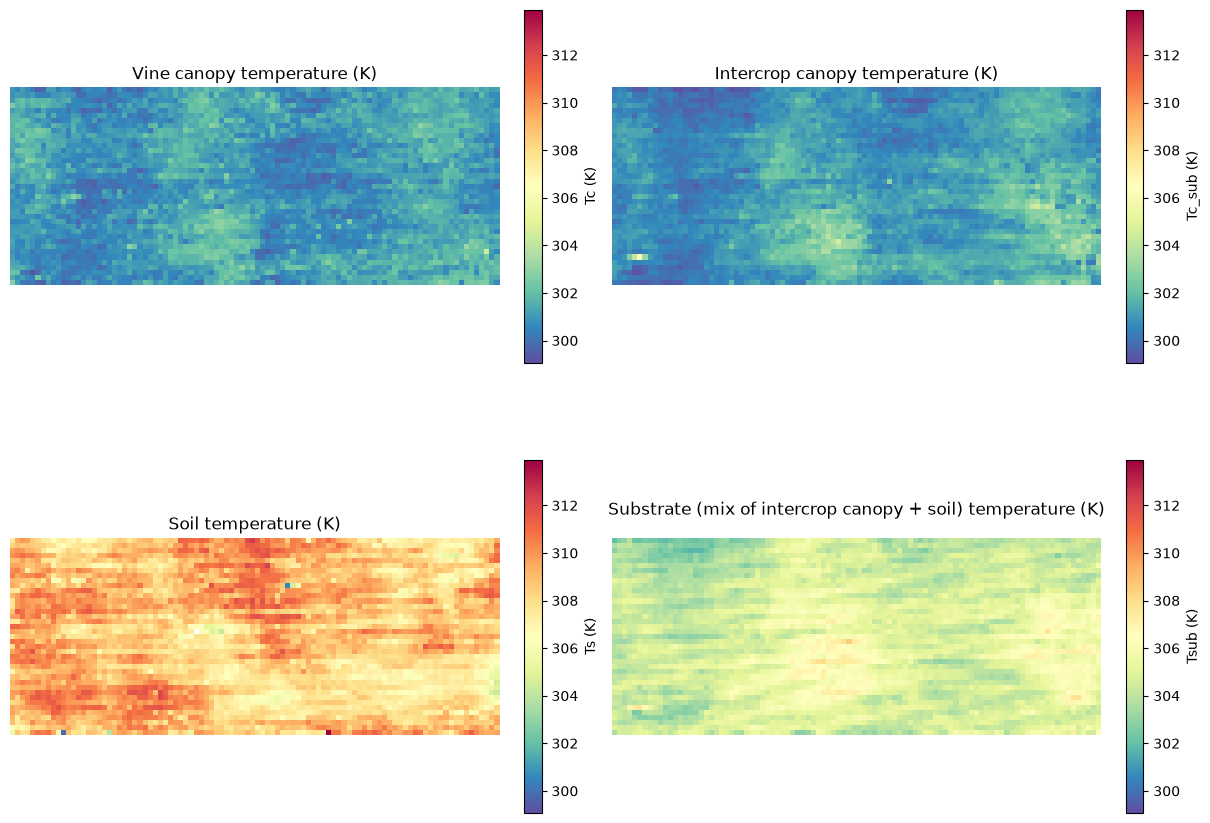

In [54]:
# --- read the 4m temperature rasters back in ---
def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1)
    return arr

Tc_4m_ar = read_raster(outfile_Tc_4m)
Tc_sub_4m_ar = read_raster(outfile_Tc_sub_4m)
Ts_4m_ar = read_raster(outfile_Ts_4m)
Tsub_4m_ar = read_raster(outfile_Tsub_4m)

# Plotting component temperatures (4m)
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

# common color scale across all four, ignoring nans
all_vals = np.concatenate([
    Tc_4m_ar[~np.isnan(Tc_4m_ar)],
    Tc_sub_4m_ar[~np.isnan(Tc_sub_4m_ar)],
    Ts_4m_ar[~np.isnan(Ts_4m_ar)],
    Tsub_4m_ar[~np.isnan(Tsub_4m_ar)]
])
vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)

# Tc
ax1 = axes[0, 0]
im1 = ax1.imshow(Tc_4m_ar, cmap='Spectral_r', vmin=vmin, vmax=vmax, extent=te)
ax1.set_title('Vine canopy temperature (K)')
ax1.set_axis_off()
cb1 = plt.colorbar(im1, ax=ax1, shrink=0.8)
cb1.set_label('Tc (K)')

# Tc_sub
ax2 = axes[0, 1]
im2 = ax2.imshow(Tc_sub_4m_ar, cmap='Spectral_r', vmin=vmin, vmax=vmax, extent=te)
ax2.set_title('Intercrop canopy temperature (K)')
ax2.set_axis_off()
cb2 = plt.colorbar(im2, ax=ax2, shrink=0.8)
cb2.set_label('Tc_sub (K)')

# Ts
ax3 = axes[1, 0]
im3 = ax3.imshow(Ts_4m_ar, cmap='Spectral_r', vmin=vmin, vmax=vmax, extent=te)
ax3.set_title('Soil temperature (K)')
ax3.set_axis_off()
cb3 = plt.colorbar(im3, ax=ax3, shrink=0.8)
cb3.set_label('Ts (K)')

# Tsub
ax4 = axes[1, 1]
im4 = ax4.imshow(Tsub_4m_ar, cmap='Spectral_r', vmin=vmin, vmax=vmax, extent=te)
ax4.set_title('Substrate (mix of intercrop canopy + soil) temperature (K)')
ax4.set_axis_off()
cb4 = plt.colorbar(im4, ax=ax4, shrink=0.8)
cb4.set_label('Tsub (K)')

plt.show()

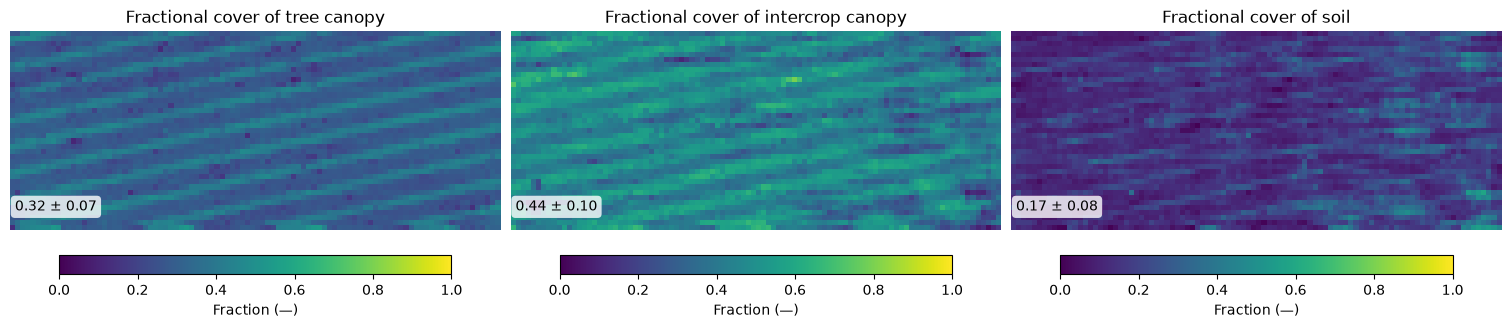

Mean and standard deviation of fractional covers:
Tree canopy: 0.32 ± 0.07
Intercrop canopy: 0.44 ± 0.10
Soil: 0.17 ± 0.08


In [81]:
# --- read the 4m fractional cover rasters back in ---
def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1)
    return arr

fc_4m_ar = read_raster(outfile_fc_4m)
fc_sub_4m_ar = read_raster(outfile_fc_sub_4m)
fs_4m_ar = read_raster(outfile_fs_4m)

bbox_props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none')

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

# Fc
ax1 = axes[0]
im1 = ax1.imshow(fc_4m_ar, cmap='viridis', vmin=0, vmax=1, extent=te)
ax1.set_title('Fractional cover of tree canopy')
ax1.set_axis_off()
cb1 = plt.colorbar(im1, ax=ax1, orientation='horizontal', shrink=0.8)
cb1.set_label('Fraction (—)')
fc_mean, fc_sd = np.nanmean(fc_4m_ar), np.nanstd(fc_4m_ar)
ax1.text(0.01, 0.1, f'{fc_mean:.2f} ± {fc_sd:.2f}', transform=ax1.transAxes, bbox=bbox_props)

# Fc_sub
ax2 = axes[1]
im2 = ax2.imshow(fc_sub_4m_ar, cmap='viridis', vmin=0, vmax=1, extent=te)
ax2.set_title('Fractional cover of intercrop canopy')
ax2.set_axis_off()
cb2 = plt.colorbar(im2, ax=ax2, orientation='horizontal', shrink=0.8)
cb2.set_label('Fraction (—)')
fc_sub_mean, fc_sub_sd = np.nanmean(fc_sub_4m_ar), np.nanstd(fc_sub_4m_ar)
ax2.text(0.01, 0.1, f'{fc_sub_mean:.2f} ± {fc_sub_sd:.2f}', transform=ax2.transAxes, bbox=bbox_props)

# Fs
ax3 = axes[2]
im3 = ax3.imshow(fs_4m_ar, cmap='viridis', vmin=0, vmax=1, extent=te)
ax3.set_title('Fractional cover of soil')
ax3.set_axis_off()
cb3 = plt.colorbar(im3, ax=ax3, orientation='horizontal', shrink=0.8)
cb3.set_label('Fraction (—)')
fs_mean, fs_sd = np.nanmean(fs_4m_ar), np.nanstd(fs_4m_ar)
ax3.text(0.01, 0.1, f'{fs_mean:.2f} ± {fs_sd:.2f}', transform=ax3.transAxes, bbox=bbox_props)

plt.show()
print('Mean and standard deviation of fractional covers:')
print(f'Tree canopy: {fc_mean:.2f} ± {fc_sd:.2f}')
print(f'Intercrop canopy: {fc_sub_mean:.2f} ± {fc_sub_sd:.2f}')
print(f'Soil: {fs_mean:.2f} ± {fs_sd:.2f}')

In [55]:
# LST
lst_file = out_dir / 'lst_surface_CC_4m.tif'
lst_fid = gdal.Open(str(lst_file))
lst_ar = lst_fid.GetRasterBand(1).ReadAsArray()
lst_ar = lst_ar + 273.15
lst_ar[np.logical_or(lst_ar<275,lst_ar>400)] = np.nan

# Tree crop temperature
Tc_file = out_dir / 'Tc_surface_CC_4m.tif'
Tc_fid = gdal.Open(str(Tc_file))
Tc_ar = Tc_fid.GetRasterBand(1).ReadAsArray()
Tc_ar[np.logical_or(Tc_ar<275,Tc_ar>400)] = np.nan

# Cover crop temperature
Tcc_file = out_dir / 'Tc_sub_surface_CC_4m.tif'
Tcc_fid = gdal.Open(str(Tcc_file))
Tcc_ar = Tcc_fid.GetRasterBand(1).ReadAsArray()
Tcc_ar[np.logical_or(Tcc_ar<275,Tcc_ar>400)] = np.nan

# Soil temperature
Ts_file = out_dir / 'Ts_surface_CC_4m.tif'
Ts_fid = gdal.Open(str(Ts_file))
Ts_ar = Ts_fid.GetRasterBand(1).ReadAsArray()
Ts_ar[np.logical_or(Ts_ar<200,Ts_ar>500)] = np.nan

# Soil temperature
Tsub_file = out_dir / 'Tsub_surface_CC_4m.tif'
Tsub_fid = gdal.Open(str(Tsub_file))
Tsub_ar = Tsub_fid.GetRasterBand(1).ReadAsArray()
Tsub_ar[np.logical_or(Tsub_ar<200,Tsub_ar>500)] = np.nan

# tree crop fractional cover
Fc_file = out_dir / 'Fc_surface_CC_4m.tif'
Fc_fid = gdal.Open(str(Fc_file))
Fc_ar = Fc_fid.GetRasterBand(1).ReadAsArray()
Fc_ar[np.isnan(lst_ar)] = np.nan

# soil fractional cover
Fs_file = out_dir / 'Fs_surface_CC_4m.tif'
Fs_fid = gdal.Open(str(Fs_file))
Fs_ar = Fs_fid.GetRasterBand(1).ReadAsArray()
Fs_ar[np.isnan(lst_ar)] = np.nan

# Cover crop fractional cover
Fcc_file = out_dir / 'Fc_sub_surface_CC_4m.tif'
Fcc_fid = gdal.Open(str(Fcc_file))
Fcc_ar = Fcc_fid.GetRasterBand(1).ReadAsArray()
Fcc_ar[np.isnan(lst_ar)] = np.nan

# the above Fcc refers to total landscape fraction of cover crop. we need to adjust this to obtain the fraction of cover crop over the substrate (cover crop + soil) because this is the input that is needed in 3SEB
Fcc_ar = Fcc_ar / (Fcc_ar+Fs_ar)

# Tree crop Canopy height model
chm_file = out_dir / 'Hc_surface_CC_4m.tif'
Hc_fid = gdal.Open(str(chm_file))
Hc_ar = Hc_fid.GetRasterBand(1).ReadAsArray()
Hc_ar[np.logical_or(Hc_ar==0,Hc_ar>10)] = np.nan

# get raster metadata 
 # get extent and info from reference dataset
prj = lst_fid.GetProjection()
ulx, xres, xskew, uly, yskew, yres = lst_fid.GetGeoTransform()
lrx = ulx + (lst_fid.RasterXSize * xres)
lry = uly + (lst_fid.RasterYSize * yres)

te = [minx, lrx, lry, uly]

### METEOROLOGY and SITE-SPECIFIC INPUTS

In [83]:
# #==============================================================================
# # study site information for ripperdan (RIP720) vineyard
# #==============================================================================

# --- Site info (RIP) ---
lat = 36.8489450
lon = -120.1755897
stdlon = -120

# Heights of measurements
z_u = 4.5  # wind speed height (m)
z_t = 4.5  # air temperature height (m)

# --- Define the timestamp of interest ---
date_ts = pd.Timestamp('2019-05-04 10:30:00')
date_mask = meteo_ds['TIMESTAMP'] == date_ts

if not date_mask.any():
    raise ValueError(f"No matching data found for {date_ts}")

# --- Time info ---
hour = date_ts.hour
doy = date_ts.dayofyear

# --- Sun angles ---
sza, saa = met.calc_sun_angles(np.ones_like(Tc_ar) * lat,
                               np.ones_like(Tc_ar) * lon,
                               np.ones_like(Tc_ar) * stdlon,
                               np.ones_like(Tc_ar) * doy,
                               np.ones_like(Tc_ar) * hour)
sza[sza > 90] = 90

# --- Meteorological variables ---
Ta = meteo_ds.loc[date_mask, 'TA_3_1_1'].values[0] + 273.15
Ta_ar = np.ones(Tc_ar.shape) * Ta

Ea = meteo_ds.loc[date_mask, 'e'].values[0] * 10  # hPa to Pa
Ea_ar = np.ones(Tc_ar.shape) * Ea

U = meteo_ds.loc[date_mask, 'WS'].values[0]
U_ar = np.ones(Tc_ar.shape) * U

P = meteo_ds.loc[date_mask, 'PA'].values[0] * 10  # kPa to Pa
P_ar = np.ones(Tc_ar.shape) * P

Sdn = meteo_ds.loc[date_mask, 'SW_IN'].values[0]
Sdn_ar = np.ones(Tc_ar.shape) * Sdn
Sdn_ar[sza > 90] = 0  # no sun at night

Sup = meteo_ds.loc[date_mask, 'SW_OUT'].values[0]
Ldn = meteo_ds.loc[date_mask, 'LW_IN'].values[0]
Ldn_ar = np.ones(Tc_ar.shape) * Ldn
Lup = meteo_ds.loc[date_mask, 'LW_OUT'].values[0]

# --- Energy fluxes ---
LE_obs = meteo_ds.loc[date_mask, 'LE'].values[0]
H_obs = meteo_ds.loc[date_mask, 'H'].values[0]
Rn_obs = meteo_ds.loc[date_mask, 'NETRAD'].values[0]
G_obs = meteo_ds.loc[date_mask, 'G_AVG'].values[0]


# --- Output dictionary ---
outdict = {
    'date': [date_ts],
    'hour': [hour],
    'SWin_obs': [Sdn],
    'SWout_obs': [Sup],
    'LWin_obs': [Ldn],
    'LWout_obs': [Lup],
    'Rn_obs': [Rn_obs],
    'LE_obs': [LE_obs],
    'H_obs': [H_obs],
    'G_obs': [G_obs]            
}

### CANOPY CHARACTERISTICS

In [ ]:
#==============================================================================
# Canopy characteristics
#==============================================================================
lai_vine = 1.8 # can also be replaced with a spatially distributed LAI map if available

lai_ar = Fc_ar * lai_vine

## cover crop
lai_cc_ar = np.ones_like(Tc_ar) * 0.8 # can also be replaced with a spatially distributed LAI map if available

# get 'ecosystem' level biophysical variables (combine tree and cover crops) for TSEB
lai_eco = lai_ar + lai_cc_ar 
Fc_eco = Fc_ar + Fcc_ar
Fc_eco[Fc_eco>1] = 1
F_eco = lai_eco/Fc_eco

# cover crop height
Hc_cc_ar = np.ones_like(Tc_ar) * 0.35 # 0.35 meters at this site based on Burchard Levine et al. 2022

# green fraction
## tree crop
Fg_ar = np.ones_like(Tc_ar) * 0.9 # less than 1 to take into account woody/non-green material
## cover crop
Fg_cc_ar = np.ones_like(Tc_ar) * 1 # assuming fully green cover crop and there is no senescence

# local LAI of cover crop
F_sub = lai_cc_ar/Fcc_ar

# row architecture and width
row_direction = 90 # N-S is 0, E-W is 90, NW-SE is 135, SW-NE is 45

## width of interrow
interrow = 3 # m

# canopy width to height ratio
wc_ratio = 1
## cover crop
wc_sub_ratio = 1

# leaf width
## tree crop
lw = 0.06 # m
## cover crop
lw_cc = 0.01 # m
x_lad = 1

# to take into account row strucure on vegetation clumping
psi = row_direction - saa

# calculate clumping index

## tree crop
Omega0 = TSEB.CI.calc_omega0_Kustas(lai_ar, Fc_ar, x_LAD=x_lad, isLAIeff=True)
Omega = TSEB.CI.calc_omega_rows(lai_ar, Fc_ar, theta=sza,
                                psi=psi, w_c=wc_ratio,
                                x_lad=x_lad)
# effective LAI (tree crop)
lai_eff =  lai_vine * Omega

## understory vegetation
Omega0_un = TSEB.CI.calc_omega0_Kustas(lai_cc_ar, Fcc_ar, x_LAD=x_lad, isLAIeff=True)
Omega_un = TSEB.CI.calc_omega_Kustas(Omega0_un, sza, w_C=wc_sub_ratio)

# effective LAI (cover crop)
lai_cc_eff =  F_sub * Omega_un

# ecosystem lai 
Omega0_eco = TSEB.CI.calc_omega0_Kustas(lai_eco, Fc_eco, x_LAD=x_lad, isLAIeff=True)
Omega_eco = TSEB.CI.calc_omega_Kustas(Omega0_eco, sza, w_C=wc_sub_ratio)
lai_eco_eff = F_eco * Omega_eco

### SPECTRA, EMISSIVITY & RADIATION TRANSMISSION

In [58]:
#==============================================================================
# Canopy and Soil spectra
#==============================================================================

spectraVeg = {'rho_leaf_vis': 0.05, 'tau_leaf_vis': 0.08, 'rho_leaf_nir': 0.26, 'tau_leaf_nir': 0.33}  # from pyTSEB
spectraGrd = {'rsoilv': 0.07, 'rsoiln': 0.28}

#Thermal spectra
e_v_constant=0.99        #Leaf emissivity
e_s_constant=0.95        #Soil emissivity

# viewing angle of sensor
vza = 0 # UAV viewing angle is considered 0 (straight above the canopy)

# for now keep constant for both layers
z0_soil=0.01

# TSEB parameters
KN_c = 0.0038  # Kondo & Ishida (1997) coefficient for rough surfaces
KN_b = 0.0120  # Kustas and Norman (1999) after Sauer and Norman (1995)

alpha_pt = 1.26 # alpha parameter in Priestley-Taylor initialization

# if using constant ratio appraoch to estimate G
# G_constant = 0.35
# calcG = [[1], G_constant] #0 = obs, 1 = modeled

# if using measured/observed values for G
G_obs = meteo_ds['G_AVG'].values[date_mask][0] 
calcG = [[0], G_obs] #0 = obs, 1 = modeled 

# use Norman and Kustas 1995 resistance framework
Resistance_flag=[0,{}]

#==============================================================================
# Emissivity
#==============================================================================

e_s = np.ones(lst_ar.shape) * e_s_constant
e_v = np.ones(lst_ar.shape) * e_v_constant

difvis, difnir, fvis, fnir = TSEB.rad.calc_difuse_ratio(Sdn_ar, sza, press=P_ar)
skyl = fvis * difvis + fnir * difnir
Sdn_dir = (1. - skyl) * Sdn_ar
Sdn_dif = skyl * Sdn_ar

# incoming long wave radiation
emisAtm = rad.calc_emiss_atm(Ea_ar, Ta_ar)
Lsky = emisAtm * met.calc_stephan_boltzmann(Ta_ar)

sn_veg, sn_soil = TSEB.rad.calc_Sn_Campbell(lai_eco, sza, Sdn_dir, Sdn_dif, fvis, fnir,
                                                    np.full_like(lai_ar, spectraVeg['rho_leaf_vis']),
                                                    np.full_like(lai_ar, spectraVeg['tau_leaf_vis']),
                                                    np.full_like(lai_ar, spectraVeg['rho_leaf_nir']),
                                                    np.full_like(lai_ar, spectraVeg['tau_leaf_nir']),
                                                    np.full_like(lai_ar, spectraGrd['rsoilv']),
                                                    np.full_like(lai_ar, spectraGrd['rsoiln']),
                                                    x_LAD=x_lad, LAI_eff=lai_eco_eff) 

sn_veg[~np.isfinite(sn_veg)] = 0
sn_soil[~np.isfinite(sn_soil)] = 0

#==============================================================================
# estimate radiation transmission using Campbell 1998 model (adapted for 3 layers)
#==============================================================================

sn_ov, sn_s, sn_un = py3seb.calc_Sn_Campbell(lai_ar,
                                       lai_cc_ar,
                                       sza,
                                       Sdn_dir,
                                       Sdn_dif,
                                       fvis,
                                       fnir,
                                       np.full_like(lai_ar, spectraVeg['rho_leaf_vis']),
                                       np.full_like(lai_ar, spectraVeg['rho_leaf_vis']),
                                       np.full_like(lai_ar, spectraVeg['tau_leaf_vis']),
                                       np.full_like(lai_ar, spectraVeg['tau_leaf_vis']),
                                       np.full_like(lai_ar, spectraVeg['rho_leaf_nir']),
                                       np.full_like(lai_ar, spectraVeg['rho_leaf_nir']),
                                       np.full_like(lai_ar, spectraVeg['tau_leaf_nir']),
                                       np.full_like(lai_ar, spectraVeg['tau_leaf_nir']),
                                       np.full_like(lai_ar, spectraGrd['rsoilv']),
                                       np.full_like(lai_ar, spectraGrd['rsoiln']),
                                       Hc_ar,
                                       0.25 * Hc_ar,
                                       wc_sub_ratio,
                                       Fc_ar,
                                       LAI_eff=lai_eff,
                                       LAI_eff_sub=lai_cc_eff)

sn_ov[~np.isfinite(sn_ov)] = 0
sn_s[~np.isfinite(sn_s)] = 0
sn_un[~np.isfinite(sn_un)] = 0


#==============================================================================
# main vegetation layer (i.e. Almond orchard)
#==============================================================================

#[z_0M, d_0] = TSEB.res.calc_roughness(lai_ar, Hc_ar, np.ones(lai_ar.shape) * wc_ratio,
 #                                     np.ones(lai_ar.shape) * TSEB.res.BROADLEAVED_D)
# calculate tree crop roughness parameters taking into account LAIeff using Raupach 1994 model
z_0M_factor, d_0_factor = py3seb.raupach_94(lai_eff)
d_0 = Hc_ar*d_0_factor
z_0M = Hc_ar*z_0M_factor

d_0[d_0 < 0] = 0
z_0M[z_0M < z0_soil] = z0_soil

# understory/secondary vegetation (i.e. Cover crop)
z_0m_un, d_0_un = TSEB.res.calc_roughness(lai_cc_eff,
                                          Hc_cc_ar,
                                           np.full_like(lai_cc_ar, wc_sub_ratio),
                                          np.full_like(lai_cc_ar, TSEB.res.GRASS))
d_0_un[d_0_un < 0] = 0
z_0m_un[z_0m_un < z0_soil] = z0_soil

In [59]:
model_outdict = {} # to save the model output parameters

### **3SEB Priestley-Taylor (3SEB-PT) Formulation**

Iteration: 0, non-converged pixels: 3744, max L diff: inf, total time: 0.000013, loop time: 0.000013
Iteration: 1, non-converged pixels: 3744, max L diff: inf, total time: 0.008086, loop time: 0.008073
Iteration: 2, non-converged pixels: 3744, max L diff: 0.627400, total time: 0.019301, loop time: 0.011215
Iteration: 3, non-converged pixels: 3744, max L diff: 0.148837, total time: 0.030135, loop time: 0.010834
Iteration: 4, non-converged pixels: 3744, max L diff: 0.056043, total time: 0.040735, loop time: 0.010600
Iteration: 5, non-converged pixels: 3740, max L diff: 0.018746, total time: 0.051694, loop time: 0.010959
Iteration: 6, non-converged pixels: 3733, max L diff: 0.006538, total time: 0.062748, loop time: 0.011054
Iteration: 7, non-converged pixels: 3, max L diff: 0.002248, total time: 0.073462, loop time: 0.010714
Finished interations with a max. L diff: 0.0007771195378154516

..Finished..



/opt/anaconda3/envs/py3seb-uav/lib/python3.14/site-packages/pyTSEB/TSEB.py:1991: RuntimeWarning: invalid value encountered in divide
  L_diff = np.asarray(np.fabs(L - L_old) / np.fabs(L_old), dtype=np.float32)


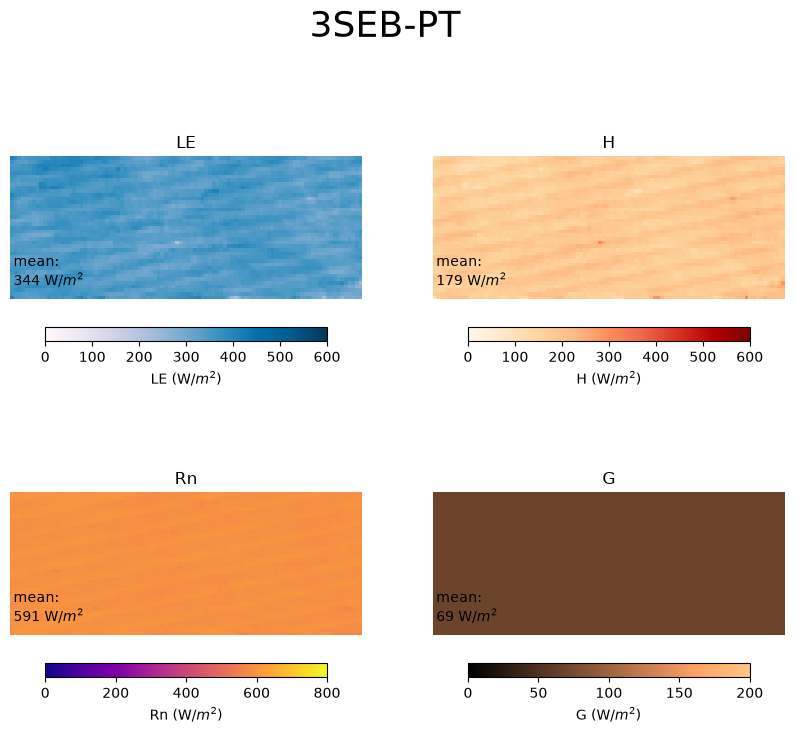

In [60]:
# 3SEB - PT

[flag_PT_all, T_S, T_C, T_C_sub, T_AC, L_n_sub, L_nC, Ln_C_sub, Ln_S, LE_C, H_C, LE_C_sub, H_C_sub,
 LE_S, H_S, G_mod, R_S, R_sub, R_X, R_A, u_friction, L, n_iterations] = py3seb.ThreeSEB_PT(lst_ar,
                                                                                         vza,
                                                                                         Ta_ar,
                                                                                         U_ar,
                                                                                         Ea_ar,
                                                                                         P_ar,
                                                                                         sn_ov,
                                                                                         sn_s,
                                                                                         sn_un,
                                                                                         Ldn_ar,
                                                                                         lai_ar,
                                                                                         lai_cc_ar,
                                                                                         Hc_ar,
                                                                                         Hc_cc_ar,
                                                                                         e_v,
                                                                                         e_v,#change e_v cover crop
                                                                                         e_s,
                                                                                         z_0M,
                                                                                         z_0m_un,
                                                                                         d_0,
                                                                                         d_0_un,
                                                                                         z_u,
                                                                                         z_t,
                                                                                         leaf_width=lw,
                                                                                         leaf_width_sub=lw_cc,
                                                                                         f_c=Fc_ar,
                                                                                         f_c_sub=Fcc_ar,
                                                                                         f_g=Fg_ar,
                                                                                         f_g_sub=Fg_cc_ar,
                                                                                         calcG_params=calcG,
                                                                                         resistance_form=Resistance_flag)
# save ouputs in outdict 
LE = LE_C + LE_C_sub + LE_S
H = H_C + H_S + H_C_sub

Rn_C = L_nC + sn_ov
Rn_C_sub = Ln_C_sub + sn_un
Rn_S = Ln_S + sn_s
Rn = Rn_C + Rn_C_sub + Rn_S

# save outputs to dictionary
model_outdict['LE_3SEB-PT'] = LE
model_outdict['LEc_3SEB-PT'] = LE_C
model_outdict['LEcc_3SEB-PT'] = LE_C_sub
model_outdict['H_3SEB-PT'] = H
model_outdict['Rn_3SEB-PT'] = Rn
model_outdict['G_3SEB-PT'] = G_mod
model_outdict['Tc_3SEB-PT'] = T_C
model_outdict['Tcc_3SEB-PT'] = T_C_sub
model_outdict['Ts_3SEB-PT'] = T_S
model_outdict['Flags_3SEB-PT'] = flag_PT_all

# visualizing outputs 

fig, axes = plt.subplots(2,2, figsize=(10,8))
ax = axes[0,0]
im = ax.imshow(LE, vmin=0, vmax=600, cmap='PuBu', extent = te)
ax.set_title('LE')
# Add colorbar for only axes[0, 0]
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', location='bottom', shrink=0.8, pad=0.1)
cbar.set_label('LE (W/$m^2$)')  # Add title to colorbar
le_mean = int(np.round(np.nanmean(LE),0))
ax.text(0.01,0.1, f'mean:\n{le_mean} W/$m^2$', transform=ax.transAxes)
ax.set_axis_off()

ax = axes[0,1]
im = ax.imshow(H, vmin=0, vmax=600, cmap='OrRd',  extent = te)
ax.set_title('H')
# Add colorbar for only axes[0, 0]
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', location='bottom', shrink=0.8, pad=0.1)
cbar.set_label('H (W/$m^2$)')  # Add title to colorbar
h_mean = int(np.round(np.nanmean(H),0))
ax.text(0.01,0.1, f'mean:\n{h_mean} W/$m^2$', transform=ax.transAxes)
ax.set_axis_off()

ax = axes[1,0]
im = ax.imshow(Rn, vmin=0, vmax=800, cmap='plasma',  extent = te)
ax.set_title('Rn')
# Add colorbar for only axes[0, 0]
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', location='bottom', shrink=0.8, pad=0.1)
cbar.set_label('Rn (W/$m^2$)')  # Add title to colorbar
rn_mean = int(np.round(np.nanmean(Rn),0))
ax.text(0.01,0.1, f'mean:\n{rn_mean} W/$m^2$', transform=ax.transAxes)
ax.set_axis_off()

ax = axes[1,1]
im = ax.imshow(G_mod, vmin=0, vmax=200, cmap='copper',  extent = te)
ax.set_title('G')
# Add colorbar for only axes[0, 0]
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', location='bottom', shrink=0.8, pad=0.1)
cbar.set_label('G (W/$m^2$)')  # Add title to colorbar
g_mean = int(np.round(np.nanmean(G_mod),0))
ax.text(0.01,0.1, f'mean:\n{g_mean} W/$m^2$', transform=ax.transAxes)
ax.set_axis_off()

plt.suptitle("3SEB-PT",
             fontsize=26)

plt.savefig(out_dir / '3SEB_PT_output.png', dpi=300, bbox_inches='tight')

plt.show()

### **3SEB Dual Temperature (3SEB-2T) Formulation**

Iteration: 0, non-converged pixels: 3744, max L diff: inf, total time: 0.000011, loop time: 0.000011
Iteration: 1, non-converged pixels: 3744, max L diff: inf, total time: 0.002598, loop time: 0.002587
Iteration: 2, non-converged pixels: 3744, max L diff: 0.519143, total time: 0.005369, loop time: 0.002771
Iteration: 3, non-converged pixels: 3744, max L diff: 0.279081, total time: 0.008351, loop time: 0.002982
Iteration: 4, non-converged pixels: 3744, max L diff: 0.244583, total time: 0.011410, loop time: 0.003059
Iteration: 5, non-converged pixels: 3734, max L diff: 0.048905, total time: 0.014596, loop time: 0.003186
Iteration: 6, non-converged pixels: 3691, max L diff: 0.010665, total time: 0.017750, loop time: 0.003154
Iteration: 7, non-converged pixels: 3483, max L diff: 0.002307, total time: 0.020649, loop time: 0.002899
Iteration: 8, non-converged pixels: 1307, max L diff: 0.000730, total time: 0.023640, loop time: 0.002991
Iteration: 9, non-converged pixels: 63, max L diff: 0.00

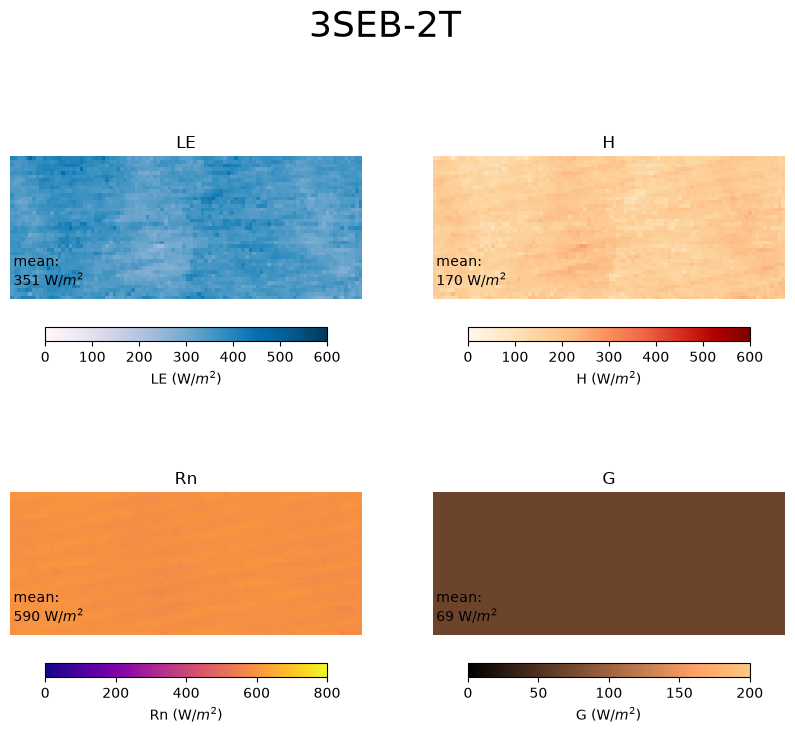

In [61]:
# 3SEB - 2T

[flag_PT_all, T_S, T_C_sub, T_AC, Ln_sub, Ln_C, Ln_C_sub, Ln_S, LE_C, H_C, LE_C_sub, H_C_sub,
LE_S, H_S, G_mod, R_sub, R_X_un, R_X_ov, R_A, u_friction, L, n_iterations] = py3seb.ThreeSEB_2T(Tc_ar,
                                                                             Tsub_ar,
                                                                             vza,
                                                                             Ta_ar,
                                                                             U_ar,
                                                                             Ea_ar,
                                                                             P_ar,
                                                                             sn_ov,
                                                                             sn_s,
                                                                             sn_un,
                                                                             Ldn_ar,
                                                                             lai_ar,
                                                                             lai_cc_ar,
                                                                             Hc_ar,
                                                                             Hc_cc_ar,
                                                                             e_v,
                                                                             e_v,#change e_v cover crop
                                                                             e_s,
                                                                             z_0M,
                                                                             z_0m_un,
                                                                             d_0,
                                                                             d_0_un,
                                                                             z_u,
                                                                             z_t,
                                                                             leaf_width=lw,
                                                                             leaf_width_sub=lw_cc,
                                                                             f_c=Fc_ar,
                                                                             f_c_sub=Fcc_ar,
                                                                             f_g=Fg_ar,
                                                                             f_g_sub=Fg_cc_ar,
                                                                             calcG_params=calcG,
                                                                             resistance_form=Resistance_flag)

# save ouputs in outdict 
LE = LE_C + LE_C_sub + LE_S
H = H_C + H_S + H_C_sub

Rn_C = Ln_C + sn_ov
Rn_C_sub = Ln_C_sub + sn_un
Rn_S = Ln_S + sn_s
Rn = Rn_C + Rn_C_sub + Rn_S
Rn[Rn>1000] = np.nan

# visualizing outputs 
# save outputs to dictionary
model_outdict['LE_3SEB-2T'] = LE
model_outdict['LEc_3SEB-2T'] = LE_C
model_outdict['LEcc_3SEB-2T'] = LE_C_sub
model_outdict['H_3SEB-2T'] = H
model_outdict['Rn_3SEB-2T'] = Rn
model_outdict['G_3SEB-2T'] = G_mod
model_outdict['Tc_3SEB-2T'] = Tc_ar
model_outdict['Tcc_3SEB-2T'] = T_C_sub
model_outdict['Ts_3SEB-2T'] = T_S
model_outdict['Flags_3SEB-2T'] = flag_PT_all

# visualize outputs
fig, axes = plt.subplots(2,2, figsize=(10,8))
ax = axes[0,0]
im = ax.imshow(LE, vmin=0, vmax=600, cmap='PuBu', extent = te)
ax.set_title('LE')
# Add colorbar for only axes[0, 0]
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', location='bottom', shrink=0.8, pad=0.1)
cbar.set_label('LE (W/$m^2$)')  # Add title to colorbar
le_mean = int(np.round(np.nanmean(LE),0))
ax.text(0.01,0.1, f'mean:\n{le_mean} W/$m^2$', transform=ax.transAxes)
ax.set_axis_off()

ax = axes[0,1]
im = ax.imshow(H, vmin=0, vmax=600, cmap='OrRd',  extent = te)
ax.set_title('H')
# Add colorbar for only axes[0, 0]
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', location='bottom', shrink=0.8, pad=0.1)
cbar.set_label('H (W/$m^2$)')  # Add title to colorbar
h_mean = int(np.round(np.nanmean(H),0))
ax.text(0.01,0.1, f'mean:\n{h_mean} W/$m^2$', transform=ax.transAxes)
ax.set_axis_off()

ax = axes[1,0]
im = ax.imshow(Rn, vmin=0, vmax=800, cmap='plasma',  extent = te)
ax.set_title('Rn')
# Add colorbar for only axes[0, 0]
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', location='bottom', shrink=0.8, pad=0.1)
cbar.set_label('Rn (W/$m^2$)')  # Add title to colorbar
rn_mean = int(np.round(np.nanmean(Rn),0))
ax.text(0.01,0.1, f'mean:\n{rn_mean} W/$m^2$', transform=ax.transAxes)
ax.set_axis_off()

ax = axes[1,1]
im = ax.imshow(G_mod, vmin=0, vmax=200, cmap='copper',  extent = te)
ax.set_title('G')
# Add colorbar for only axes[0, 0]
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', location='bottom', shrink=0.8, pad=0.1)
cbar.set_label('G (W/$m^2$)')  # Add title to colorbar
g_mean = int(np.round(np.nanmean(G_mod),0))
ax.text(0.01,0.1, f'mean:\n{g_mean} W/$m^2$', transform=ax.transAxes)
ax.set_axis_off()

plt.suptitle("3SEB-2T",
             fontsize=26)

plt.savefig(out_dir / '3SEB_2T_output.png', dpi=300, bbox_inches='tight')

plt.show()

### **3SEB Triple Temperature (3SEB-3T) Formulation**

Iteration: 0, non-converged pixels: 3744, max L diff: inf, total time: 0.000008, loop time: 0.000007
Iteration: 1, non-converged pixels: 3744, max L diff: inf, total time: 0.001429, loop time: 0.001421
Iteration: 2, non-converged pixels: 3744, max L diff: inf, total time: 0.003010, loop time: 0.001581
Iteration: 3, non-converged pixels: 3744, max L diff: inf, total time: 0.004595, loop time: 0.001585
Iteration: 4, non-converged pixels: 3744, max L diff: inf, total time: 0.006065, loop time: 0.001470
Iteration: 5, non-converged pixels: 3744, max L diff: inf, total time: 0.007622, loop time: 0.001557
Iteration: 6, non-converged pixels: 3462, max L diff: inf, total time: 0.009411, loop time: 0.001789
Iteration: 7, non-converged pixels: 1, max L diff: inf, total time: 0.010930, loop time: 0.001519
Iteration: 8, non-converged pixels: 1, max L diff: inf, total time: 0.011333, loop time: 0.000403
Iteration: 9, non-converged pixels: 1, max L diff: inf, total time: 0.011674, loop time: 0.000341

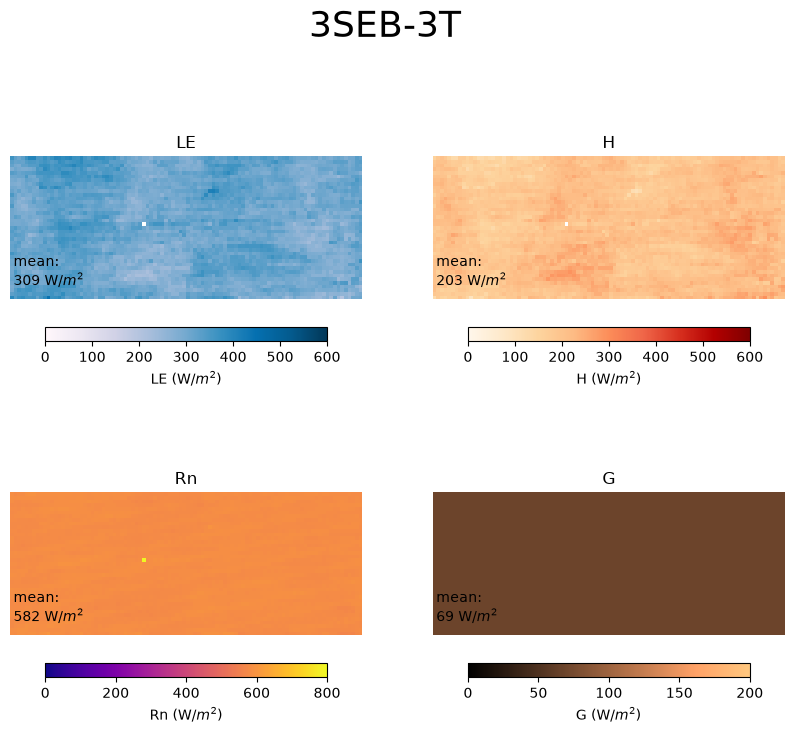

In [62]:
# 3SEB - 3T 

[flag_PT_all, T_AC, L_nC, Ln_C_sub, Ln_S, LE_C, H_C, LE_C_sub, H_C_sub,
LE_S, H_S, G_mod, R_S, R_x_un,R_x_ov, R_A, u_friction, L, n_iterations] = py3seb.ThreeSEB_3T(Tc_ar,
                                                                                     Tcc_ar,
                                                                                     Ts_ar,
                                                                                     Ta_ar,
                                                                                     U_ar,
                                                                                     Ea_ar,
                                                                                     P_ar,
                                                                                     sn_ov,
                                                                                     sn_s,
                                                                                     sn_un,
                                                                                     Ldn_ar,
                                                                                     lai_ar,
                                                                                     lai_cc_ar,
                                                                                     Hc_ar,
                                                                                     Hc_cc_ar,
                                                                                     e_v,
                                                                                     e_v,#change e_v cover crop
                                                                                     e_s,
                                                                                     z_0M,
                                                                                     z_0m_un,
                                                                                     d_0,
                                                                                     d_0_un,
                                                                                     z_u,
                                                                                     z_t,
                                                                                     leaf_width=lw,
                                                                                     leaf_width_sub=lw_cc,
                                                                                     f_c=Fc_ar,
                                                                                     f_c_sub=Fcc_ar,
                                                                                     f_g=Fg_ar,
                                                                                     f_g_sub=Fg_cc_ar,
                                                                                     calcG_params=calcG,
                                                                                     resistance_form=Resistance_flag)

# save ouputs in outdict 
LE = LE_C + LE_C_sub + LE_S
H = H_C + H_S + H_C_sub

Rn_C = L_nC + sn_ov
Rn_C_sub = Ln_C_sub + sn_un
Rn_S = Ln_S + sn_s
Rn = Rn_C + Rn_C_sub + Rn_S
Rn[Rn>1000] = np.nan
G_mod[G_mod>200] = np.nan
G_mod = np.where(np.isnan(Rn), np.nan, G_mod) # fix for the G raster showing a square

# visualizing outputs 
# save outputs to dictionary
model_outdict['LE_3SEB-3T'] = LE
model_outdict['LEc_3SEB-3T'] = LE_C
model_outdict['LEcc_3SEB-3T'] = LE_C_sub
model_outdict['H_3SEB-3T'] = H
model_outdict['Rn_3SEB-3T'] = Rn
model_outdict['G_3SEB-3T'] = G_mod
model_outdict['Tc_3SEB-3T'] = Tc_ar
model_outdict['Tcc_3SEB-3T'] = Tcc_ar
model_outdict['Ts_3SEB-3T'] = Ts_ar
model_outdict['Flags_3SEB-3T'] = flag_PT_all

# visualizing outputs 

fig, axes = plt.subplots(2,2, figsize=(10,8))
ax = axes[0,0]
im = ax.imshow(LE, vmin=0, vmax=600, cmap='PuBu', extent = te)
ax.set_title('LE')
# Add colorbar for only axes[0, 0]
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', location='bottom', shrink=0.8, pad=0.1)
cbar.set_label('LE (W/$m^2$)')  # Add title to colorbar
le_mean = int(np.round(np.nanmean(LE),0))
ax.text(0.01,0.1, f'mean:\n{le_mean} W/$m^2$', transform=ax.transAxes)
ax.set_axis_off()

ax = axes[0,1]
im = ax.imshow(H, vmin=0, vmax=600, cmap='OrRd',  extent = te)
ax.set_title('H')
# Add colorbar for only axes[0, 0]
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', location='bottom', shrink=0.8, pad=0.1)
cbar.set_label('H (W/$m^2$)')  # Add title to colorbar
h_mean = int(np.round(np.nanmean(H),0))
ax.text(0.01,0.1, f'mean:\n{h_mean} W/$m^2$', transform=ax.transAxes)
ax.set_axis_off()

ax = axes[1,0]
im = ax.imshow(Rn, vmin=0, vmax=800, cmap='plasma',  extent = te)
ax.set_title('Rn')
# Add colorbar for only axes[0, 0]
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', location='bottom', shrink=0.8, pad=0.1)
cbar.set_label('Rn (W/$m^2$)')  # Add title to colorbar
rn_mean = int(np.round(np.nanmean(Rn),0))
ax.text(0.01,0.1, f'mean:\n{rn_mean} W/$m^2$', transform=ax.transAxes)
ax.set_axis_off()

ax = axes[1,1]
im = ax.imshow(G_mod, vmin=0, vmax=200, cmap='copper',  extent = te)
ax.set_title('G')
# Add colorbar for only axes[0, 0]
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', location='bottom', shrink=0.8, pad=0.1)
cbar.set_label('G (W/$m^2$)')  # Add title to colorbar
g_mean = int(np.round(np.nanmean(G_mod),0))
ax.text(0.01,0.1, f'mean:\n{g_mean} W/$m^2$', transform=ax.transAxes)
ax.set_axis_off()

plt.suptitle("3SEB-3T",
             fontsize=26)

plt.savefig(out_dir / '3SEB_3T_output.png', dpi=300, bbox_inches='tight')

plt.show()

***View the model outputs values in table format for comparison***

In [63]:
# observed data are saved in outdict

model_types = ['3SEB-PT','3SEB-2T','3SEB-3T']
fluxes = ['LE', 'H', 'Rn', 'G']

for model in model_types:
    for var in fluxes:
        var_ar = model_outdict[f'{var}_{model}']
        flags =  model_outdict[f'Flags_{model}']
        var_ar[var_ar<-100] = np.nan
        var_ar[var_ar>1000] = np.nan
        var_ar[flags > 5] = np.nan
        avg_w = np.nanmean(var_ar)
        
        outdict[f'{var}_{model}'] = []
        outdict[f'{var}_{model}'].append(avg_w)

results_df = pd.DataFrame(outdict)

for model in model_types:
    print(f"\nModel: {model}")
    for var in fluxes:
        key = f"{var}_{model}"
        val = outdict.get(key, [np.nan])[0]
        print(f"  {var}: {val:.2f}")


Model: 3SEB-PT
  LE: 343.54
  H: 178.61
  Rn: 591.18
  G: 69.03

Model: 3SEB-2T
  LE: 350.74
  H: 170.31
  Rn: 590.08
  G: 69.03

Model: 3SEB-3T
  LE: 309.44
  H: 203.17
  Rn: 581.72
  G: 69.03


### **Compare 3SEB flux values against eddy covariance observations**

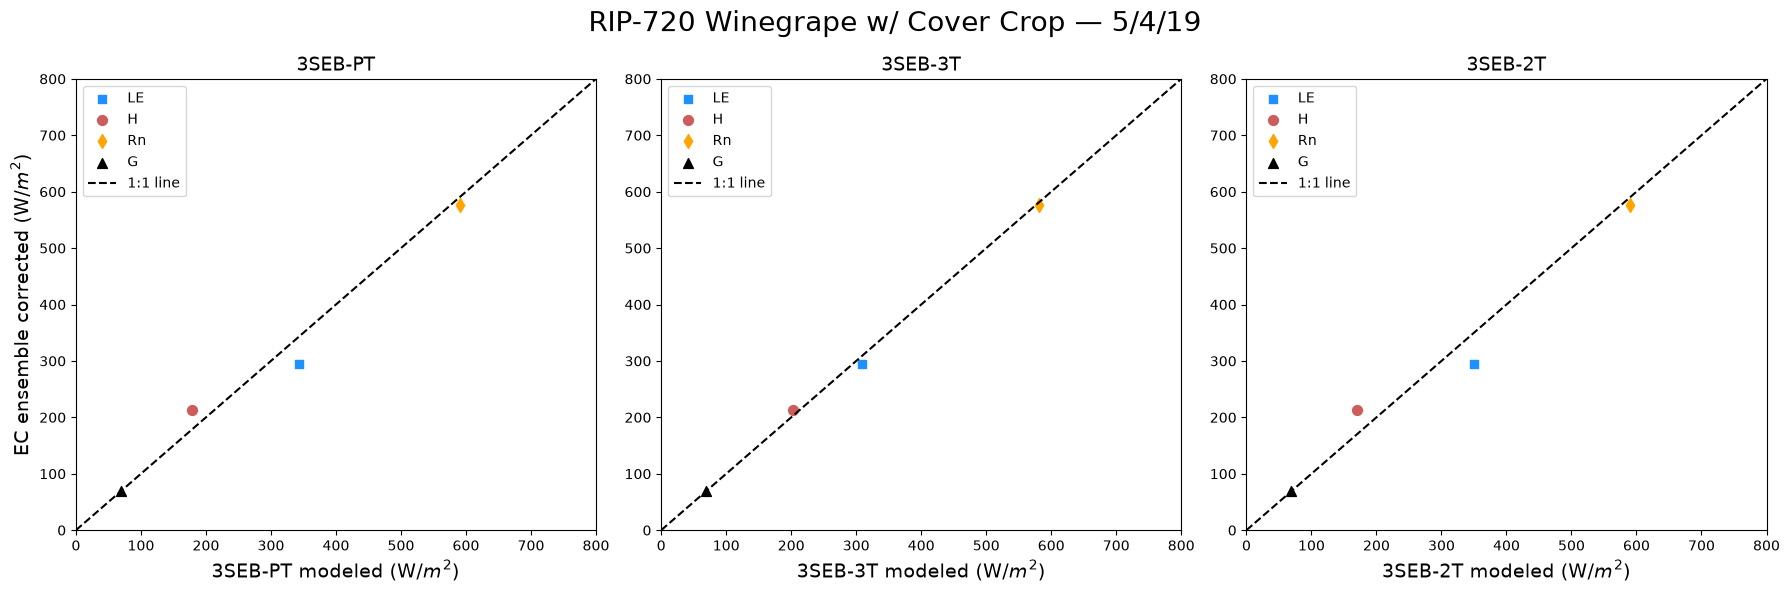

In [64]:
# plot results
import scipy.stats as st
model_types = ['3SEB-PT', '3SEB-3T', '3SEB-2T']
h_obs = results_df['H_obs'].values
Rn_obs = results_df['Rn_obs'].values
G_obs = results_df['G_obs'].values
le_obs = results_df['LE_obs'].values
ec_res = Rn_obs - h_obs - le_obs - G_obs
le_res = Rn_obs - h_obs - G_obs
bowen_ratio = h_obs / le_obs
le_bowen = (Rn_obs - G_obs) / (1 + bowen_ratio)
le_ens = (le_obs + le_bowen + le_res) / 3
h_ens = Rn_obs - G_obs - le_ens

# Create 1x3 subplot grid
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Define positions: column index for each model
positions = {
    '3SEB-PT': 0,
    '3SEB-3T': 1,
    '3SEB-2T': 2,
}

for model_type in model_types:
    # Get model outputs
    h_mod = results_df[f'H_{model_type}'].values
    Rn_mod = results_df[f'Rn_{model_type}'].values
    G_mod = results_df[f'G_{model_type}'].values
    le_mod = results_df[f'LE_{model_type}'].values
    
    # Get subplot position
    col = positions[model_type]
    ax = axes[col]
    
    # Plot data
    ax.scatter(le_mod, le_ens, color='dodgerblue', marker='s', label='LE', s=30)
    ax.scatter(h_mod, h_ens, color='indianred', marker='o', label='H', s=50)
    ax.scatter(Rn_mod, Rn_obs, color='orange', marker='d', label='Rn', s=50)
    ax.scatter(G_mod[G_obs > 0], G_obs[G_obs > 0], color='k', marker='^', label='G', s=50)
    ax.plot((0, 800), (0, 800), color='k', label='1:1 line', linestyle='--')
    ax.legend()
    ax.set_xlim(0, 800)
    ax.set_ylim(0, 800)
    ax.set_xlabel(f'{model_type} modeled (W/$m^2$)', fontsize=14)
    
    # Add y-label only for leftmost plot
    if col == 0:
        ax.set_ylabel('EC ensemble corrected (W/$m^2$)', fontsize=14)
    
    ax.set_title(f'{model_type}', fontsize=14)

fig.suptitle("RIP-720 Winegrape w/ Cover Crop — 5/4/19", fontsize=20)
plt.tight_layout()
plt.show()